# Lab: Building an Interactive Dashboard

In the lecture, we built a dashboard one piece at a time. In this lab, you will bring together the analysis workflow, Plotly figures, and Dash components to create an interactive dashboard using a dataset of your choosing.

Your dashboard should help a specific audience answer a focused question. The goal is not to fit every possible chart onto one page. Select a small set of related evidence, organize it clearly, and give the user one useful way to interact with it.



## Learning goals

By the end of this lab, you should be able to:

- use the reproducible analysis workflow to plan a dashboard;
- prepare and check data before displaying it;
- create Plotly figures that answer related questions;
- organize text, controls, and figures in a Dash layout;
- connect an interactive control to figures with a callback; and
- explain the conclusion and limitations of a dashboard.



## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding every part of the submitted work, testing the dashboard, citing the dataset, and checking that the evidence supports your conclusion. Do not submit private, confidential, or personally identifying data to an AI system.



## Assignment requirements

Choose a dataset that supports a meaningful comparison. It should contain:

- enough observations to reveal a pattern rather than a few isolated cases;
- at least one categorical feature that can be used as an interactive filter or comparison;
- at least two additional useful features, which may be categorical, quantitative, temporal, spatial, or text-derived; and
- enough documentation for you to explain what the records and selected features represent.

The completed dashboard must contain:

- a descriptive title and a short explanation of its purpose;
- at least two related Plotly figures;
- at least one dropdown menu or radio-button control;
- at least one callback that updates both figures;
- human-readable titles, labels, categories, and colors;
- stable axes or category orders when changing them would make comparisons misleading; and
- a brief conclusion and limitation displayed on the page.



# Step 1: Question



## 1. Identify the audience

A dashboard should be designed for someone. Identify a realistic audience and explain what decision, judgment, or understanding the dashboard could support.



**Who is the intended audience, and why would this evidence be useful to them?**
The intended audience is movie fans. The dashboard can help them compare movie genres and ratings to find movies they may want to watch.


## 2. State the research question

Write one focused question that your two figures will help answer. The question should name the main features or groups being compared.



**What question will the dashboard answer?**

How do movie ratings and popularity differ across different movie genres?

## 3. Make a prediction



**What pattern do you expect to find, and what informed that prediction?**

I expect some movie genres to have higher ratings and popularity than others because different genres attract different audiences and levels of interest.

# Step 2: Data



## 4. Import the libraries

Import Pandas, Plotly Express, and the Dash objects used in the lecture: `Dash`, `dcc`, `html`, `Input`, and `Output`.



In [4]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output


## 5. Document the dataset

Give the dataset title, its creator or publisher, a working link or citation, the time period represented, and any relevant collection or sampling information.



**Where did the data come from, and what does its documentation tell you about how it was collected?**

The data comes from the TMDB 5000 Movie Dataset, which contains information on about 5,000 movies from The Movie Database (TMDB). It includes genres, ratings, popularity, release dates, budgets, and revenue. The movies in the dataset span many years, from older films through movies released around 2016. The dataset was published on Kaggle using data from TMDB.

## 6. Read the data

Read the dataset into a Pandas DataFrame. Give the DataFrame a short, descriptive name.



In [5]:
movies = pd.read_csv("data/tmdb_5000_movies.csv")



## 7. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.



In [6]:
display(movies.head())
display(movies.tail())
movies.info()
display(movies.isnull().sum())


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],2011-12-26,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""id"": 3958}...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2013-10-13,0,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,"Signed, Sealed, Delivered",7.0,6
4801,0,[],http://shanghaicalling.com/,126186,[],en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,[],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-05-03,0,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7
4802,0,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,25975,"[{""id"": 1523, ""name"": ""obsession""}, {""id"": 224...",en,My Date with Drew,Ever since the second grade when he first saw ...,1.929883,"[{""name"": ""rusty bear entertainment"", ""id"": 87...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2005-08-05,0,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,My Date with Drew,6.3,16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

**Complete the table for every feature you expect to use. Add or remove rows as needed.**

| Feature | What it represents | Data storage type | Feature type | Missing values | Dashboard role |
|---|---|---|---|---:|---|
| `title` | Movie title | object | Categorical | 0 | Identifies each movie |
| `genres` | Movie genre or genres | object | Categorical | 0 | Interactive filter |
| `popularity` | TMDB popularity score | float64 | Quantitative | 0 | Popularity comparison |
| `vote_average` | Average movie rating | float64 | Quantitative | 0 | Rating comparison |



**What does one row of the original dataset represent?**

One row represents one movie and its information, such as genre, popularity, rating, release date, budget, and revenue.

# Step 3: Operation



## 8. Create the analysis DataFrame

Select the features needed for the dashboard and use `.copy()` to create a DataFrame named `analysis`. Handle missing values in a way that is appropriate for the question. If values need clearer labels or corrected storage types, make those changes here.



In [8]:
analysis = movies[
    ["title", "genres", "popularity", "vote_average"]
].copy()


**How did you handle missing values, and why was that choice appropriate?**

I selected only the features needed for the dashboard. These features had no missing values, so no rows needed to be removed.

## 9. Create any calculated features

If the dashboard needs a calculated category, date component, percentage, rate, or other calculated feature, create it here. If no calculated feature is needed, leave the code cell blank and explain why.



In [9]:
import ast

analysis["genre"] = analysis["genres"].apply(
    lambda x: ast.literal_eval(x)[0]["name"] if ast.literal_eval(x) else "Unknown"
)


**What calculated feature or cleaned label did you create, and how will it support the dashboard?**

I created a simplified genre feature using each movie’s first listed genre. This gives the dashboard a clear category to use for filtering and comparison.

## 10. Prepare the control options

Create the labels and values for the dropdown or radio-button control. The visible labels should be understandable to someone who has not seen the original column names.



In [10]:
genre_options = [
    {"label": genre, "value": genre}
    for genre in sorted(analysis["genre"].unique())
]

genre_options[:5]


[{'label': 'Action', 'value': 'Action'},
 {'label': 'Adventure', 'value': 'Adventure'},
 {'label': 'Animation', 'value': 'Animation'},
 {'label': 'Comedy', 'value': 'Comedy'},
 {'label': 'Crime', 'value': 'Crime'}]

# Step 4: Check



## 11. Check the prepared data

Display the first rows of `analysis`, its stored data types, missing-value counts, and appropriate summaries or frequency counts for the dashboard features.



In [11]:
display(analysis.head())
analysis.info()
display(analysis.isnull().sum())
display(analysis["genre"].value_counts())
display(analysis[["popularity", "vote_average"]].describe())


,title,genres,popularity,vote_average,genre
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150.437577,7.2,Action
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139.082615,6.9,Adventure
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107.376788,6.3,Action
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",112.312950,7.6,Action
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43.926995,6.1,Action


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4803 non-null   object 
 1   genres        4803 non-null   object 
 2   popularity    4803 non-null   float64
 3   vote_average  4803 non-null   float64
 4   genre         4803 non-null   object 
dtypes: float64(2), object(3)
memory usage: 187.7+ KB


title           0
genres          0
popularity      0
vote_average    0
genre           0
dtype: int64

genre
Drama              1207
Comedy             1042
Action              754
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          89
Family               56
Mystery              41
Music                34
Unknown              28
Western              27
History              25
War                  24
TV Movie              4
Foreign               2
Name: count, dtype: int64

,popularity,vote_average
count,4803.000000,4803.000000
mean,21.492301,6.092172
std,31.816650,1.194612
min,0.000000,0.000000
25%,4.668070,5.600000
50%,12.921594,6.200000
75%,28.313505,6.800000
max,875.581305,10.000000


## 12. Check the interactive groups

Calculate the number of observations available for every control option. Make sure each option returns data and that unexpectedly small groups are understood before building the callback.



In [12]:
analysis["genre"].value_counts()



genre
Drama              1207
Comedy             1042
Action              754
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          89
Family               56
Mystery              41
Music                34
Unknown              28
Western              27
History              25
War                  24
TV Movie              4
Foreign               2
Name: count, dtype: int64

**What did these checks establish about the data that will appear in the dashboard?**

The checks confirmed that all selected features have data and every genre has movies available for the dashboard, although some genres have much smaller groups than others.

# Step 5: Evidence



## 13. Create the first static Plotly figure

Build the first figure before placing it in Dash. Give it a descriptive title and human-readable axis and legend labels.



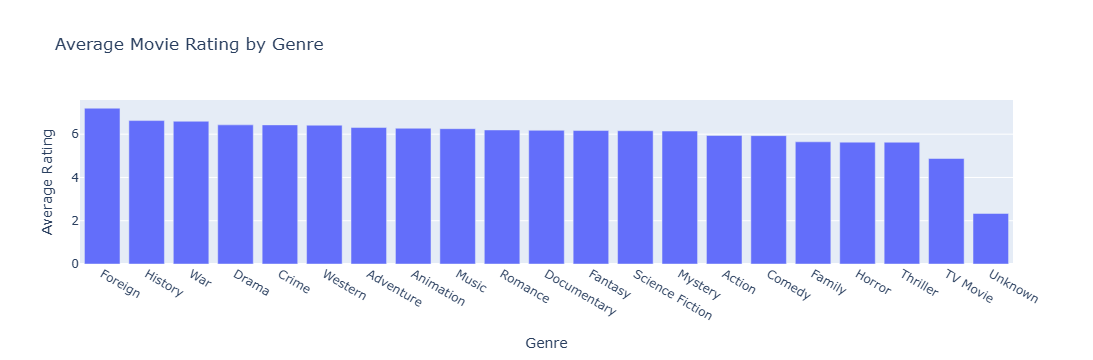

In [13]:
rating_by_genre = (
    analysis.groupby("genre", as_index=False)["vote_average"]
    .mean()
    .sort_values("vote_average", ascending=False)
)

fig1 = px.bar(
    rating_by_genre,
    x="genre",
    y="vote_average",
    title="Average Movie Rating by Genre",
    labels={
        "genre": "Genre",
        "vote_average": "Average Rating"
    }
)

fig1.show()



**What evidence should a viewer obtain from the first figure?**

The first figure shows how average movie ratings differ across genres and which genres tend to have higher or lower ratings.

## 14. Create the second static Plotly figure

The second figure should add different but related evidence rather than repeat the first figure in another style.



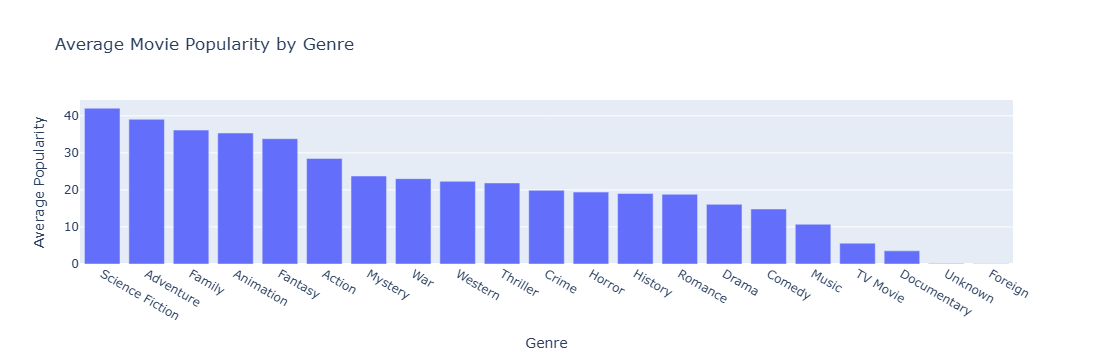

In [14]:
popularity_by_genre = (
    analysis.groupby("genre", as_index=False)["popularity"]
    .mean()
    .sort_values("popularity", ascending=False)
)

fig2 = px.bar(
    popularity_by_genre,
    x="genre",
    y="popularity",
    title="Average Movie Popularity by Genre",
    labels={
        "genre": "Genre",
        "popularity": "Average Popularity"
    }
)

fig2.show()



**What does the second figure add to the first figure's evidence?**

The second figure shows which genres are more popular, so viewers can compare popularity with average ratings.

## 15. Plan the dashboard



**Complete the dashboard plan before writing the app. Add rows if needed.**

| Component | What it displays or controls | Why it belongs on the dashboard |
|---|---|---|
| Title and introduction | Explains that the dashboard compares movie ratings and popularity by genre | Helps the viewer understand the purpose |
| Interactive control | Dropdown menu for selecting a movie genre | Lets the viewer focus on one genre at a time |
| First figure | Movie ratings for the selected genre | Shows how movies in the genre are rated |
| Second figure | Movie popularity for the selected genre | Shows how popular movies in the genre are |
| Conclusion and limitation | Summarizes the main pattern and explains limits of the data | Helps the viewer interpret the results correctly |



## 16. Create reusable figure code

Write a function that accepts the selected control value, filters or summarizes `analysis`, creates both Plotly figures, and returns the figures in a consistent order. Fix axis ranges or category orders when they need to remain stable across selections.



In [20]:
def make_figures(selected_genre):
    filtered = analysis[
        analysis["genre"] == selected_genre
    ].copy()

    fig1 = px.bar(
        filtered.sort_values("vote_average", ascending=False).head(15),
        x="title",
        y="vote_average",
        title=f"Top Rated {selected_genre} Movies",
        labels={
            "title": "Movie",
            "vote_average": "Average Rating"
        }
    )

    fig1.update_yaxes(range=[0, 10])

    fig2 = px.bar(
        filtered.sort_values("popularity", ascending=False).head(15),
        x="title",
        y="popularity",
        title=f"Most Popular {selected_genre} Movies",
        labels={
            "title": "Movie",
            "popularity": "Popularity"
        }
    )

    fig2.update_yaxes(
        range=[0, analysis["popularity"].max()]
    )

    return fig1, fig2



## 17. Build the layout

Create a Dash app and its layout. Include the title, purpose statement, interactive control, two empty `dcc.Graph` components with unique IDs, and short conclusion and limitation statements.



In [16]:
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Movie Ratings and Popularity Dashboard"),

    html.P(
        "Use the dropdown to compare ratings and popularity for different movie genres."
    ),

    dcc.Dropdown(
        id="genre-dropdown",
        options=genre_options,
        value="Action",
        clearable=False
    ),

    dcc.Graph(id="rating-graph"),
    dcc.Graph(id="popularity-graph"),

    html.H3("Conclusion"),
    html.P(
        "Movie genres differ in both average ratings and popularity."
    ),

    html.H3("Limitation"),
    html.P(
        "Some genres contain far fewer movies than others, so comparisons should be interpreted carefully."
    )
])



## 18. Connect the callback

Connect the control's `value` to the `figure` property of both graphs. The callback function should call the reusable figure function and return its two figures in the same order as the two outputs.



In [17]:
@app.callback(
    Output("rating-graph", "figure"),
    Output("popularity-graph", "figure"),
    Input("genre-dropdown", "value")
)
def update_graphs(selected_genre):
    return make_figures(selected_genre)



## 19. Check the callback as a Python function

Call the callback or reusable figure function with at least two valid control values. Confirm that each call returns two Plotly figures without an error.



In [18]:
test1 = make_figures("Action")
test2 = make_figures("Comedy")

print(len(test1))
print(len(test2))



2
2


## 20. Run the dashboard

Run the app in a browser tab. Use a port that is not already occupied by another app, and stop the app before restarting the same code.



In [19]:
app.run(debug=True, port=8051)



**After testing every control option, what did you revise or confirm about the dashboard's behavior?**

I confirm that the drop down works and both graphs update correctly when a different genre is selected.

**Which design choice most improves the dashboard's readability or usefulness?**

The genre dropped down improves the dashboard the most because it lets the viewer focus on one genre at a time and keeps the charts easier to read.

# Step 6: Conclusion



**State a concise conclusion that directly answers the research question and refers to evidence visible in the dashboard.**

Movie ratings and popularity differ across genres, and the dashboard shows that some genres have higher-rated or more popular movies than others.

**How does the interactive control help the audience examine the evidence?**

The dropdown lets the viewer select a genre and compare its movie ratings and popularity in both charts.

# Step 7: Limitation



**State one important limitation on how the dashboard's evidence should be interpreted.**

Some genres have far fewer movies than others, so their average ratings and popularity may be less reliable for comparison.

## AI-use reflection



**Describe any AI assistance you used. Identify one suggestion you verified, revised, or rejected. If you did not use AI, state that.**

I used ChatGPT to help check my code and written answers. I verified the dashboard code by testing different genres and confirmed that both graphs updated correctly.

## Submission checklist

Before submitting, confirm that:

- [ ] every prompt has one complete response;
- [ ] all notebook cells run in order without an error;
- [ ] the dashboard opens and every control option works;
- [ ] the two figures use readable titles, labels, categories, and colors;
- [ ] comparable views retain stable axes or category orders when needed;
- [ ] the dataset source is cited and the required data file accompanies the submission;
- [ ] the notebook and dashboard code are organized and readable;
- [ ] the conclusion and limitation are supported by the displayed evidence; and
- [ ] the work is submitted by the deadline.

